In [1]:
# conda env : spatial

import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import cell2location
import squidpy as sq
import json
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
import numpy as np
from scipy.spatial import distance
from scipy.spatial.distance import cdist
from sklearn.decomposition import NMF

/home/jaehyunchoi/.conda/envs/spatial/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/jaehyunchoi/.conda/envs/spatial/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/jaehyunchoi/.conda/envs/spatial/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/jaehyunchoi/.conda/envs/spatial/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/jaehyunchoi/.conda/envs/spatial/lib/python3.10/site-packages/anndata/utils.py:429: Futur

# Merging slide data

In [2]:
path = "/home/jaehyunchoi/bystander_collaboration/IPF_data/S-BSST1410/analysis/Radial_distance/data"
samples = ["092A1","092B1","092C1","092D1","015A1", "015B1","015C1", "015D1","019A1","051B1","051C1",
           "051D1","279B1","279C1","279D1","280A1","280B1","280C1","280D1", "281A1","281B1","281C1", "281D1","282A1","282B1"]  # 폴더 이름들

# 결과 저장 딕셔너리
adata_dict = {}
scalef_dict = {}

for sample in samples:
    # h5ad 불러오기
    adata_path = os.path.join(path, sample, f"adata_{sample}_c2l.h5ad")
    adata = sc.read(adata_path)
    
    # scalefactor 계산
    json_path = os.path.join(path, sample, "scalefactors_json.json")
    with open(json_path, "r") as f:
        scale_dict = json.load(f)
    spotf = scale_dict['spot_diameter_fullres']
    scalef = 55 / spotf
    
    # 딕셔너리에 저장
    adata_dict[sample] = adata
    scalef_dict[sample] = scalef
adata_dict

{'092A1': AnnData object with n_obs × n_vars = 4199 × 13949
     obs: 'in_tissue', 'array_row', 'array_col', 'sample', '_indices', '_scvi_batch', '_scvi_labels', 'ATI', 'ATII', 'Aberrant_Basaloid', 'B', 'B_Plasma', 'Basal', 'Ciliated', 'Club', 'DC_Langerhans', 'DC_Mature', 'Fibroblast', 'Goblet', 'ILC_A', 'ILC_B', 'Ionocyte', 'Lymphatic', 'Macrophage', 'Macrophage_Alveolar', 'Mast', 'Mesothelial', 'Myofibroblast', 'NK', 'PNEC', 'Pericyte', 'SMC', 'T_CD4', 'T_Cytotoxic', 'T_PD1high', 'T_Regulatory', 'VE_Arterial', 'VE_Capillary_A', 'VE_Capillary_B', 'VE_Peribronchial', 'VE_Venous', 'cDC1', 'cDC2', 'cMonocyte', 'ncMonocyte', 'pDC', 'annotation'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'mod', 'spatial'
     obsm: 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'spatial', 'stds_cell_abundance_w_sf',
 '092B1': AnnData object with n_obs × n_vars = 4121 × 13949
     obs: 'in_tissue', 'array_row', 'array_col', 'sample', '_indices', '_scvi_batch', '_scvi_

In [3]:
samples = ["092A1","092B1","092C1","092D1","015A1", "015B1","015C1", "015D1","019A1","051B1","051C1",
           "051D1","279B1","279C1","279D1","280A1","280B1","280C1","280D1", "281A1","281B1","281C1", "281D1","282A1","282B1"]
for sample in samples:
    locals()[f"adata_{sample}"] = adata_dict[sample]
    locals()[f"scalef_{sample}"] = scalef_dict[sample]

In [4]:
samples = ["092A1","092B1","092C1","092D1","015A1", "015B1","015C1", "015D1","019A1","051B1","051C1",
           "051D1","279B1","279C1","279D1","280A1","280B1","280C1","280D1", "281A1","281B1","281C1", "281D1","282A1","282B1"]

processed_adatas = []

for sample in samples:
    adata = adata_dict[sample].copy()
    scalef = scalef_dict[sample]
    
    coords = adata.obsm["spatial"]
    # sample 이름 저장
    adata.obs["sample"] = sample
    
    processed_adatas.append(adata)

adata_merged = processed_adatas[0].concatenate(
    *processed_adatas[1:],
    batch_key="sample_batch",
    batch_categories=samples
)
adata_merged

/tmp/ipykernel_2413106/4011870304.py:16: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = processed_adatas[0].concatenate(


AnnData object with n_obs × n_vars = 101907 × 13949
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', '_indices', '_scvi_batch', '_scvi_labels', 'ATI', 'ATII', 'Aberrant_Basaloid', 'B', 'B_Plasma', 'Basal', 'Ciliated', 'Club', 'DC_Langerhans', 'DC_Mature', 'Fibroblast', 'Goblet', 'ILC_A', 'ILC_B', 'Ionocyte', 'Lymphatic', 'Macrophage', 'Macrophage_Alveolar', 'Mast', 'Mesothelial', 'Myofibroblast', 'NK', 'PNEC', 'Pericyte', 'SMC', 'T_CD4', 'T_Cytotoxic', 'T_PD1high', 'T_Regulatory', 'VE_Arterial', 'VE_Capillary_A', 'VE_Capillary_B', 'VE_Peribronchial', 'VE_Venous', 'cDC1', 'cDC2', 'cMonocyte', 'ncMonocyte', 'pDC', 'annotation', 'sample_batch'
    obsm: 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'spatial', 'stds_cell_abundance_w_sf'

In [5]:
library_ids = {}
for sample, ad in adata_dict.items():
    if "spatial" in ad.uns:
        key = list(ad.uns["spatial"].keys())[0]  # usually only one key
        library_ids[sample] = key

print(library_ids)

{'092A1': 'V19S23-092-A1', '092B1': 'V19S23-092-B1', '092C1': 'V19S23-092-C1', '092D1': 'V19S23-092-D1', '015A1': 'V10T31-015-A1', '015B1': 'V10T31-015-B1', '015C1': 'V10T31-015-C1', '015D1': 'V10T31-015-D1', '019A1': 'V10T31-019-A1', '051B1': 'V10T31-051-B1', '051C1': 'V10T31-051-C1', '051D1': 'V10T31-051-D1', '279B1': 'V10T03-279-B1', '279C1': 'V10T03-279-C1', '279D1': 'V10T03-279-D1', '280A1': 'V10T03-280-A1', '280B1': 'V10T03-280-B1', '280C1': 'V10T03-280-C1', '280D1': 'V10T03-280-D1', '281A1': 'V10T03-281-A1', '281B1': 'V10T03-281-B1', '281C1': 'V10T03-281-C1', '281D1': 'V10T03-281-D1', '282A1': 'V10T03-282-A1', '282B1': 'V10T03-282-B1'}


In [6]:
adata_merged.uns["spatial"] = {}

for sample, lib_id in library_ids.items():
    adata_merged.uns["spatial"][sample] = adata_dict[sample].uns["spatial"][lib_id]

In [7]:
adata_merged

AnnData object with n_obs × n_vars = 101907 × 13949
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', '_indices', '_scvi_batch', '_scvi_labels', 'ATI', 'ATII', 'Aberrant_Basaloid', 'B', 'B_Plasma', 'Basal', 'Ciliated', 'Club', 'DC_Langerhans', 'DC_Mature', 'Fibroblast', 'Goblet', 'ILC_A', 'ILC_B', 'Ionocyte', 'Lymphatic', 'Macrophage', 'Macrophage_Alveolar', 'Mast', 'Mesothelial', 'Myofibroblast', 'NK', 'PNEC', 'Pericyte', 'SMC', 'T_CD4', 'T_Cytotoxic', 'T_PD1high', 'T_Regulatory', 'VE_Arterial', 'VE_Capillary_A', 'VE_Capillary_B', 'VE_Peribronchial', 'VE_Venous', 'cDC1', 'cDC2', 'cMonocyte', 'ncMonocyte', 'pDC', 'annotation', 'sample_batch'
    uns: 'spatial'
    obsm: 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'spatial', 'stds_cell_abundance_w_sf'

In [17]:
adata_merged.write("/home/jaehyunchoi/bystander_collaboration/Figure_script_IPF/Data/revision/Visium/vis_c2l.h5ad")

# Bar graph of various celltype Density Across Histological Categories

In [8]:
adata=sc.read("/home/jaehyunchoi/bystander_collaboration/Figure_script_IPF/Data/revision/Visium/vis_c2l.h5ad")
adata

AnnData object with n_obs × n_vars = 101907 × 13949
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', '_indices', '_scvi_batch', '_scvi_labels', 'ATI', 'ATII', 'Aberrant_Basaloid', 'B', 'B_Plasma', 'Basal', 'Ciliated', 'Club', 'DC_Langerhans', 'DC_Mature', 'Fibroblast', 'Goblet', 'ILC_A', 'ILC_B', 'Ionocyte', 'Lymphatic', 'Macrophage', 'Macrophage_Alveolar', 'Mast', 'Mesothelial', 'Myofibroblast', 'NK', 'PNEC', 'Pericyte', 'SMC', 'T_CD4', 'T_Cytotoxic', 'T_PD1high', 'T_Regulatory', 'VE_Arterial', 'VE_Capillary_A', 'VE_Capillary_B', 'VE_Peribronchial', 'VE_Venous', 'cDC1', 'cDC2', 'cMonocyte', 'ncMonocyte', 'pDC', 'annotation', 'sample_batch'
    uns: 'spatial'
    obsm: 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'spatial', 'stds_cell_abundance_w_sf'

In [20]:
adata.obs['slide'] = adata.obs['sample'].str[-2]
adata.obs['slide'] = adata.obs['slide'].astype('category')

print("New 'slide' column created in adata.obs:")
print(adata.obs['slide'].value_counts())
print("\nExample of sample to slide mapping:")
print(adata.obs[['sample', 'slide']].head())

New 'slide' column created in adata.obs:
slide
B    27798
C    25869
A    25199
D    23041
Name: count, dtype: int64

Example of sample to slide mapping:
                               sample slide
AAACAACGAATAGTTC-1-092A1-092A1  092A1     A
AAACAAGTATCTCCCA-1-092A1-092A1  092A1     A
AAACAATCTACTAGCA-1-092A1-092A1  092A1     A
AAACACCAATAACTGC-1-092A1-092A1  092A1     A
AAACAGAGCGACTCCT-1-092A1-092A1  092A1     A


In [28]:
# --- Setup: Assuming 'adata' is your AnnData object ---

CELL_TYPE_COLUMN = 'T_PD1high'
GROUP_COLUMN = 'annotation'

# Check Data Availability
if CELL_TYPE_COLUMN not in adata.obs.columns or GROUP_COLUMN not in adata.obs.columns:
    print(f"Error: Required column '{CELL_TYPE_COLUMN}' or '{GROUP_COLUMN}' not found in adata.obs.")
    exit()

In [29]:
# Calculate Mean Abundance per Annotation Group
# Extract the relevant columns for easier handling
df_plot = adata.obs[[CELL_TYPE_COLUMN, GROUP_COLUMN]].copy()

# Calculate the mean (average) abundance of the cell type for each group
mean_abundance = df_plot.groupby(GROUP_COLUMN)[CELL_TYPE_COLUMN].mean().sort_values(ascending=False)

# Convert the results back to a DataFrame for plotting
mean_abundance_df = mean_abundance.reset_index(name='Mean Abundance')

print("Mean T_PD1high Abundance per Annotation Group (Top 10):")
print(mean_abundance_df.head(10))

Mean T_PD1high Abundance per Annotation Group (Top 10):
                  annotation  Mean Abundance
0               Inflammation        0.575464
1           Suspect Fibrosis        0.227208
2                   Diseased        0.225957
3               Large Airway        0.141207
4               Blood Vessel        0.123573
5  Normal Alveolar and Other        0.108399


/tmp/ipykernel_1608399/1537436928.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_abundance = df_plot.groupby(GROUP_COLUMN)[CELL_TYPE_COLUMN].mean().sort_values(ascending=False)


/tmp/ipykernel_1608399/3272746999.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


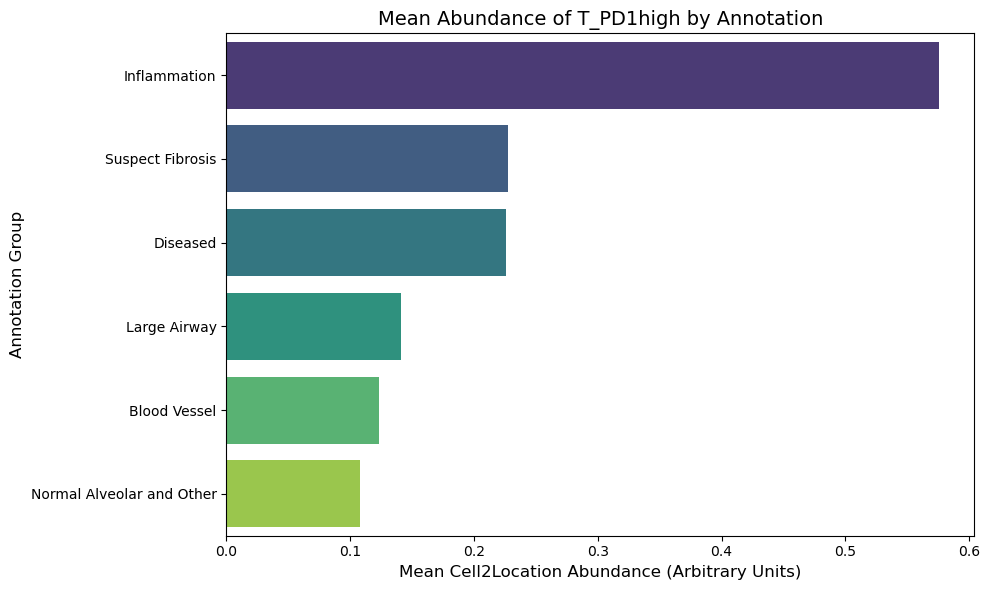

In [30]:
# --- Visualization (Bar Plot for Mean) ---

plt.figure(figsize=(10, 6))
sns.barplot(
    data=mean_abundance_df,
    x='Mean Abundance',
    y=GROUP_COLUMN,
    order=mean_abundance_df[GROUP_COLUMN],
    palette='viridis'
)

plt.title(f'Mean Abundance of {CELL_TYPE_COLUMN} by Annotation', fontsize=14)
plt.xlabel('Mean Cell2Location Abundance (Arbitrary Units)', fontsize=12)
plt.ylabel('Annotation Group', fontsize=12)
plt.tight_layout()

# PDF로 저장
plt.savefig("/home/jaehyunchoi/bystander_collaboration/Figure_script_IPF/Figures/revision/Visium/Mean_T_PD1_bargraph.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()


/tmp/ipykernel_1608399/3722989172.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


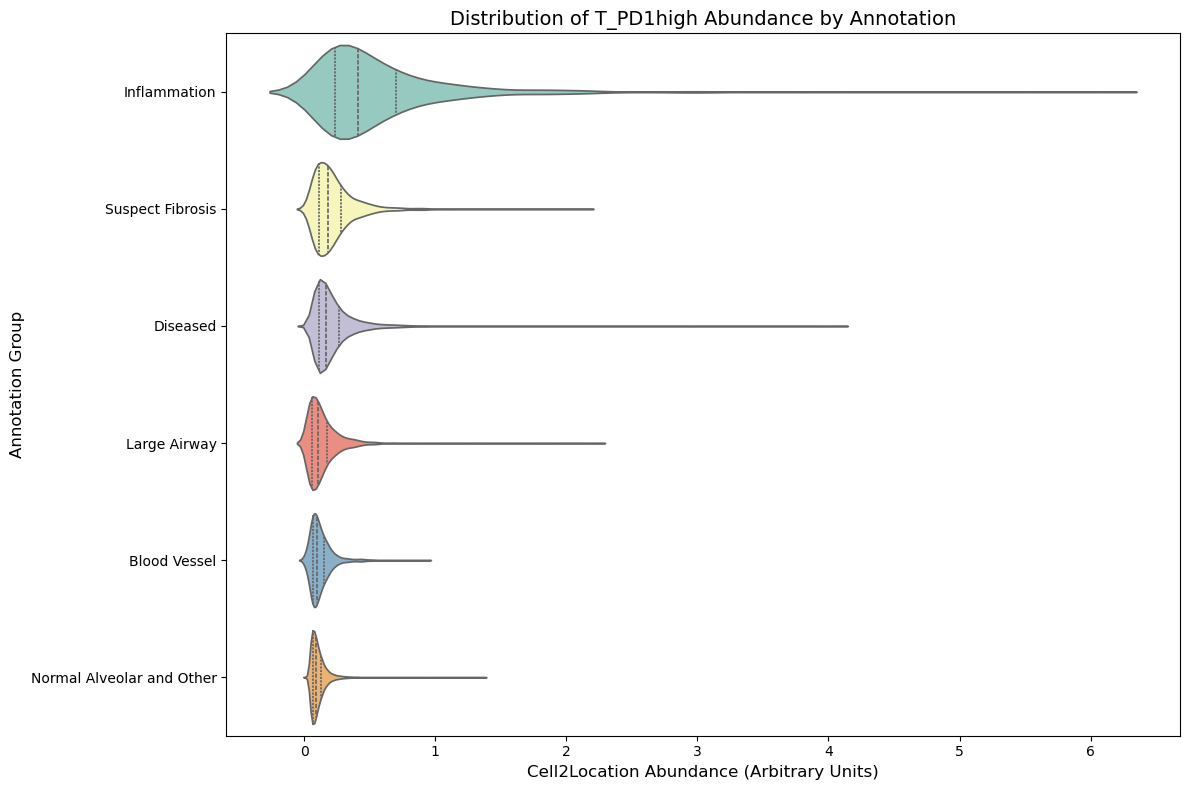

In [31]:
# --- Alternative Visualization (Box/Violin Plot for Distribution) ---
# This shows the distribution and outliers, not just the mean.

plt.figure(figsize=(12, 8))
sns.violinplot(
    data=df_plot,
    x=CELL_TYPE_COLUMN,
    y=GROUP_COLUMN,
    # Ensure the order is based on the mean abundance calculated previously
    order=mean_abundance_df[GROUP_COLUMN],
    inner='quartile', # Show quartiles inside the violin
    palette='Set3'
)

plt.title(f'Distribution of {CELL_TYPE_COLUMN} Abundance by Annotation', fontsize=14)
plt.xlabel('Cell2Location Abundance (Arbitrary Units)', fontsize=12)
plt.ylabel('Annotation Group', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
adata.obs['state'] = adata.obs['sample_batch']
adata.obs['state'] = adata.obs['state'].replace({
    '279C1':'IPF',
    '281B1':'IPF',
    '279D1':'IPF',
    '015C1':'IPF',
    '280B1':'IPF',
    '092C1':'IPF',
    '282A1':'Healthy',
    '051D1':'IPF',
    '280A1':'Healthy',
    '019A1':'Healthy',
    '280C1':'IPF',
    '092A1':'Healthy',
    '015B1':'IPF',
    '092B1':'IPF',
    '281A1':'Healthy',
    '279B1':'IPF',
    '092D1':'IPF',
    '281C1':'IPF',
    '051C1':'IPF',
    '015A1':'Healthy',
    '281D1':'IPF',
    '015D1' :'IPF',
    '282B1':'IPF',
    '280D1':'IPF',
    '051B1':'IPF'})

/tmp/ipykernel_2413106/4253024403.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['state'] = adata.obs['state'].replace({


Mann–Whitney U test: U = 1507555298.50, p = 0.000e+00


/tmp/ipykernel_2413106/3076872709.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_abundance = df_plot.groupby(GROUP_COLUMN)[CELL_TYPE_COLUMN].mean()
/tmp/ipykernel_2413106/3076872709.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


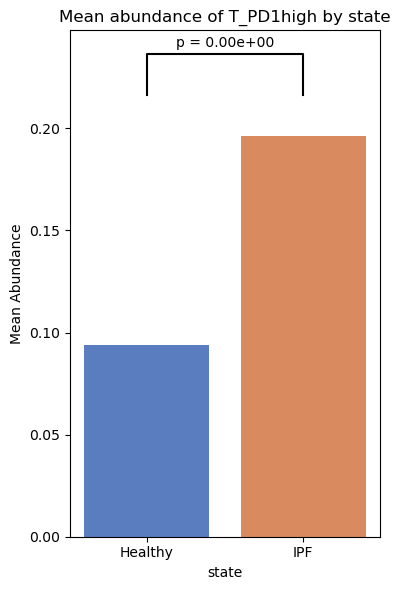

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

CELL_TYPE_COLUMN = 'T_PD1high'
GROUP_COLUMN = 'state'

# Mann–Whitney U test(IPF vs Healthy)
df_plot = adata.obs[[CELL_TYPE_COLUMN, GROUP_COLUMN]].copy()
group_healthy = df_plot[df_plot[GROUP_COLUMN] == "Healthy"][CELL_TYPE_COLUMN]
group_ipf     = df_plot[df_plot[GROUP_COLUMN] == "IPF"][CELL_TYPE_COLUMN]

stat, pval = mannwhitneyu(group_ipf, group_healthy, alternative='greater')
print(f"Mann–Whitney U test: U = {stat:.2f}, p = {pval:.3e}")

# Calculate mean abundance
mean_abundance = df_plot.groupby(GROUP_COLUMN)[CELL_TYPE_COLUMN].mean()
mean_abundance_df = mean_abundance.reset_index(name='Mean Abundance')

# Barplot + p-value
plt.figure(figsize=(4, 6))
ax = sns.barplot(
    data=mean_abundance_df,
    x=GROUP_COLUMN,
    y='Mean Abundance',
    palette='muted'
)

# p-value text adding
x1, x2 = 0, 1
y, h, col = mean_abundance_df['Mean Abundance'].max() + 0.02, 0.02, 'k'
ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c=col)
ax.text((x1 + x2) * .5, y + h + 0.002, f"p = {pval:.2e}", ha='center', va='bottom', color=col)

plt.title(f'Mean abundance of {CELL_TYPE_COLUMN} by state')
plt.tight_layout()
plt.show()

Mann–Whitney U test: U = 1577178736.50, p = 0.000e+00


/tmp/ipykernel_2413106/2826426773.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_abundance = df_plot.groupby(GROUP_COLUMN)[CELL_TYPE_COLUMN].mean()
/tmp/ipykernel_2413106/2826426773.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


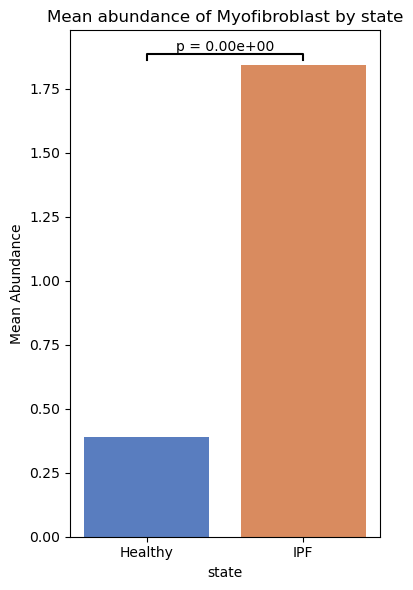

In [17]:
CELL_TYPE_COLUMN = 'Myofibroblast'
GROUP_COLUMN = 'state'

# Mann–Whitney U test(IPF vs Healthy)
df_plot = adata.obs[[CELL_TYPE_COLUMN, GROUP_COLUMN]].copy()
group_healthy = df_plot[df_plot[GROUP_COLUMN] == "Healthy"][CELL_TYPE_COLUMN]
group_ipf     = df_plot[df_plot[GROUP_COLUMN] == "IPF"][CELL_TYPE_COLUMN]

stat, pval = mannwhitneyu(group_ipf, group_healthy, alternative='greater')
print(f"Mann–Whitney U test: U = {stat:.2f}, p = {pval:.3e}")

# Calculate mean abundance
mean_abundance = df_plot.groupby(GROUP_COLUMN)[CELL_TYPE_COLUMN].mean()
mean_abundance_df = mean_abundance.reset_index(name='Mean Abundance')

# Barplot + p-value
plt.figure(figsize=(4, 6))
ax = sns.barplot(
    data=mean_abundance_df,
    x=GROUP_COLUMN,
    y='Mean Abundance',
    palette='muted'
)

# p-value text adding
x1, x2 = 0, 1
y, h, col = mean_abundance_df['Mean Abundance'].max() + 0.02, 0.02, 'k'
ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c=col)
ax.text((x1 + x2) * .5, y + h + 0.002, f"p = {pval:.2e}", ha='center', va='bottom', color=col)

plt.title(f'Mean abundance of {CELL_TYPE_COLUMN} by state')
plt.tight_layout()
plt.show()

# NMF factor clustering

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [32]:
adata=sc.read("/home/jaehyunchoi/bystander_collaboration/Figure_script_IPF/Data/revision/Visium/vis_c2l.h5ad")
adata

AnnData object with n_obs × n_vars = 101907 × 13949
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', '_indices', '_scvi_batch', '_scvi_labels', 'ATI', 'ATII', 'Aberrant_Basaloid', 'B', 'B_Plasma', 'Basal', 'Ciliated', 'Club', 'DC_Langerhans', 'DC_Mature', 'Fibroblast', 'Goblet', 'ILC_A', 'ILC_B', 'Ionocyte', 'Lymphatic', 'Macrophage', 'Macrophage_Alveolar', 'Mast', 'Mesothelial', 'Myofibroblast', 'NK', 'PNEC', 'Pericyte', 'SMC', 'T_CD4', 'T_Cytotoxic', 'T_PD1high', 'T_Regulatory', 'VE_Arterial', 'VE_Capillary_A', 'VE_Capillary_B', 'VE_Peribronchial', 'VE_Venous', 'cDC1', 'cDC2', 'cMonocyte', 'ncMonocyte', 'pDC', 'annotation', 'sample_batch'
    uns: 'spatial'
    obsm: 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'spatial', 'stds_cell_abundance_w_sf'

In [33]:
n_factors = 30

nmf_model = NMF(n_components=n_factors, init='random', random_state=42, max_iter=200)
W = nmf_model.fit_transform(adata.X)
H = nmf_model.components_

/home/jaehyunchoi/.conda/envs/spatial/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1692: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [34]:
# W (cell factors) goes into adata.obsm['X_nmf']
adata.obsm['X_nmf'] = W

# Create a DataFrame for gene loadings, matching the R structure
factor_names = [f"factor_{i}" for i in range(1, n_factors + 1)]
gene_loadings_df = pd.DataFrame(
    H.T,  # Transpose H so genes are rows
    index=adata.var_names,
    columns=factor_names
)
print("NMF complete. Gene loadings stored in a DataFrame.")

NMF complete. Gene loadings stored in a DataFrame.


In [35]:
adata.uns['nmf_gene_loadings'] = gene_loadings_df
gene_loadings_df

,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,factor_10,...,factor_21,factor_22,factor_23,factor_24,factor_25,factor_26,factor_27,factor_28,factor_29,factor_30
A1BG,0.010399,0.000000,0.000000,0.000000,0.265941,0.077114,0.003861,0.000000,0.000000,0.300273,...,0.000000,0.109920,0.159333,0.000000,0.000000,0.031013,0.023339,0.015080,0.195722,0.335714
A2M,0.383898,0.000000,1.290159,0.000000,0.000000,0.696285,0.761842,2.162683,0.842302,2.184224,...,0.000000,7.433606,20.800285,0.000000,0.000000,2.183717,0.752412,0.041050,6.125576,229.696091
A4GALT,0.009301,0.000000,0.000000,0.025665,0.124339,0.036418,0.005780,0.108144,0.000000,0.443449,...,0.000000,0.042154,0.038915,0.000000,0.109637,0.015562,0.000000,0.005479,0.022693,0.613763
AAAS,0.000582,0.001802,0.000000,0.017217,0.256071,0.032611,0.052308,0.008697,0.045244,0.255558,...,0.000000,0.007910,0.000000,0.000000,0.253583,0.016083,0.001179,0.033225,0.000000,0.240214
AACS,0.000000,0.001409,0.000601,0.017984,0.168621,0.009495,0.021168,0.126736,0.059410,0.161002,...,0.000000,0.000000,0.009749,0.000000,0.028347,0.009960,0.000000,0.019997,0.000000,0.092133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,0.000000,0.000000,0.005764,0.011878,0.153597,0.004830,0.027722,0.059288,0.042617,0.090806,...,0.003504,0.022484,0.000000,0.024900,0.368761,0.000933,0.000000,0.000377,0.004578,0.095017
ZYG11A,0.000000,0.000000,0.000020,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000367,0.000339,0.000000,0.000026,0.000006,0.000000,0.000000,0.001258
ZYG11B,0.000000,0.001699,0.004267,0.000000,0.044025,0.011917,0.051008,0.000000,0.064456,0.094225,...,0.001750,0.000000,0.008451,0.323159,1.001517,0.021727,0.000000,0.011002,0.000000,0.300568
ZYX,0.011477,0.013168,0.000000,0.000000,0.000000,0.367500,0.738643,0.358943,0.102580,0.000000,...,0.002561,0.329860,0.000000,0.616258,3.649397,0.203054,0.009536,0.073711,0.577582,5.214682


In [36]:
top_n_genes = 100

# Use a list comprehension to process each factor
factor_gene_loadings = []

for factor_x in range(1, n_factors + 1):
    factor_name = f"factor_{factor_x}"
    print(f"Processing {factor_name}")

    # Extract the loadings for the current factor
    feat_loads = gene_loadings_df[[factor_name]].copy()
    feat_loads.columns = ["gene_loading"]

    # R's Scale01(x) scales values to [0, 1]. In Python, we can use MinMaxScaler or simple min-max:
    min_val = feat_loads['gene_loading'].min()
    max_val = feat_loads['gene_loading'].max()
    feat_loads['gene_loading_scaled'] = (feat_loads['gene_loading'] - min_val) / (max_val - min_val)

    feat_loads['gene'] = feat_loads.index
    feat_loads['factor'] = factor_x

    # Select top N genes based on 'gene_loading'
    feat_loads_top = feat_loads.sort_values(
        by='gene_loading', ascending=False
    ).head(top_n_genes).copy() # The .copy() is important to avoid SettingWithCopyWarning

    # Calculate rank (equivalent to dplyr::dense_rank(desc(gene_loading)))
    # For ties, pandas rank() default 'average' is fine, but 'dense' is closer to R's dense_rank
    feat_loads_top['rank'] = feat_loads_top['gene_loading'].rank(
        method='dense', ascending=False
    ).astype(int) # Convert to integer rank

    factor_gene_loadings.append(feat_loads_top)

Processing factor_1
Processing factor_2
Processing factor_3
Processing factor_4
Processing factor_5
Processing factor_6
Processing factor_7
Processing factor_8
Processing factor_9
Processing factor_10
Processing factor_11
Processing factor_12
Processing factor_13
Processing factor_14
Processing factor_15
Processing factor_16
Processing factor_17
Processing factor_18
Processing factor_19
Processing factor_20
Processing factor_21
Processing factor_22
Processing factor_23
Processing factor_24
Processing factor_25
Processing factor_26
Processing factor_27
Processing factor_28
Processing factor_29
Processing factor_30


In [37]:
NMF_KEY = 'X_nmf' 
C2L_CELL_TYPES = [
    'ATI', 'ATII', 'Aberrant_Basaloid', 'B', 'B_Plasma', 'Basal', 'Ciliated',
    'Club', 'DC_Langerhans', 'DC_Mature', 'Fibroblast', 'Goblet', 'ILC_A',
    'ILC_B', 'Ionocyte', 'Lymphatic', 'Macrophage', 'Macrophage_Alveolar',
    'Mast', 'Mesothelial', 'Myofibroblast', 'NK', 'PNEC', 'Pericyte', 'SMC',
    'T_CD4', 'T_Cytotoxic', 'T_PD1high', 'T_Regulatory', 'VE_Arterial',
    'VE_Capillary_A', 'VE_Capillary_B', 'VE_Peribronchial', 'VE_Venous',
    'cDC1', 'cDC2', 'cMonocyte', 'ncMonocyte', 'pDC'
]

# Load NMF factor loadings from adata.obsm
try:
    nmf_loadings = pd.DataFrame(
        adata.obsm[NMF_KEY],
        index=adata.obs_names,
        columns=[f"NMF_Factor_{i}" for i in range(1, adata.obsm[NMF_KEY].shape[1] + 1)]
    )
    print(f"Successfully loaded NMF loadings with {nmf_loadings.shape[1]} factors.")
except KeyError:
    print(f"Error: NMF loadings not found at adata.obsm['{NMF_KEY}']. Please check the key.")
    exit() # Stop execution if NMF data is missing

# Load Cell2Location cell type abundance from adata.obs
try:
    c2l_abundance = adata.obs[C2L_CELL_TYPES].copy()
    # Ensure indices match (they should, as both come from adata)
    common_spots = nmf_loadings.index.intersection(c2l_abundance.index)
    nmf_loadings = nmf_loadings.loc[common_spots]
    c2l_abundance = c2l_abundance.loc[common_spots]
    print(f"Successfully loaded Cell2Location abundance for {c2l_abundance.shape[1]} cell types.")
except KeyError:
    print("Error: One or more cell type columns not found in adata.obs. Check the column list.")
    exit() # Stop execution if C2L data is missing


Successfully loaded NMF loadings with 30 factors.
Successfully loaded Cell2Location abundance for 39 cell types.


In [40]:
# Concatenate the two matrices (spots x NMF_factors + cell_types)
combined_data = pd.concat([nmf_loadings, c2l_abundance], axis=1)

# Calculate the Spearman rank-correlation matrix for all features
# Note: Using .values for `spearmanr` and then reconstructing the DataFrame is generally faster
correlation_matrix, p_values = spearmanr(combined_data.values)
correlation_matrix = pd.DataFrame(
    correlation_matrix,
    index=combined_data.columns,
    columns=combined_data.columns
)

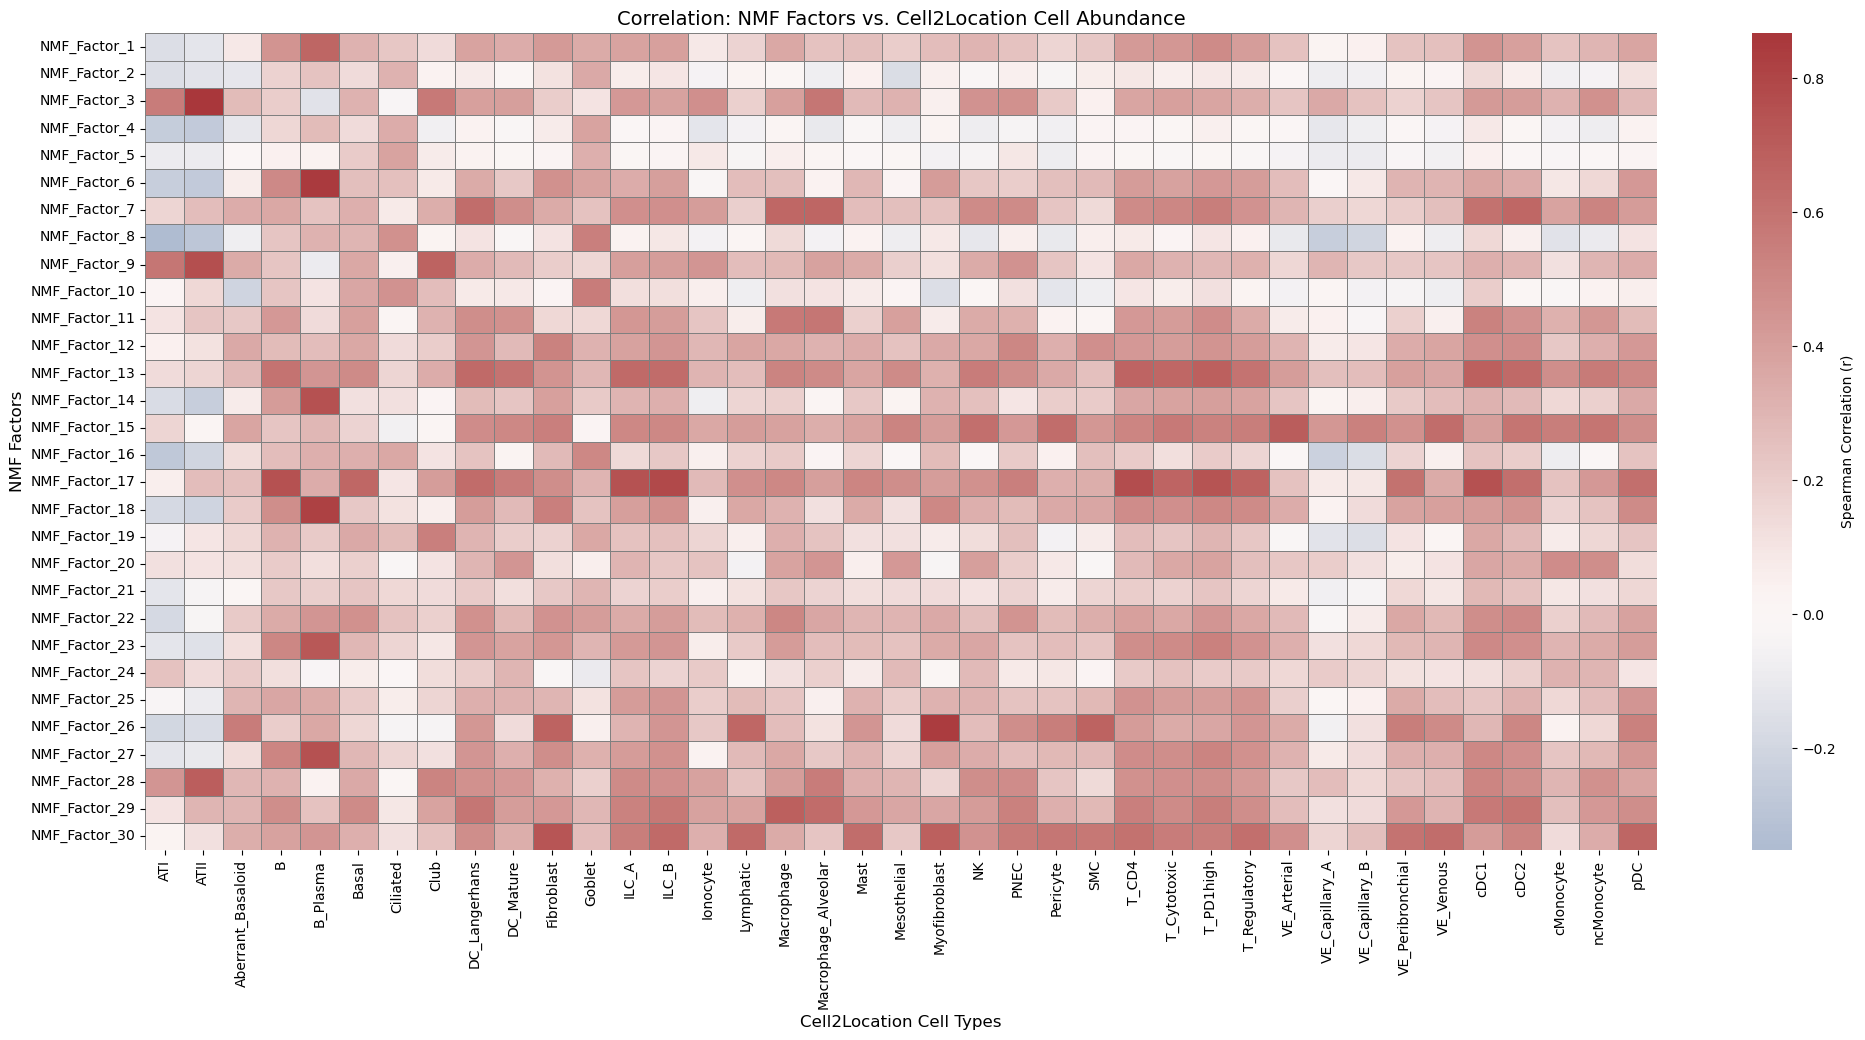


--- Strongest Associations ---
Top correlated NMF Factor (by magnitude) for each Cell Type:
ATI                     NMF_Factor_9
ATII                    NMF_Factor_3
Aberrant_Basaloid      NMF_Factor_26
B                      NMF_Factor_17
B_Plasma                NMF_Factor_6
Basal                  NMF_Factor_17
Ciliated                NMF_Factor_8
Club                    NMF_Factor_9
DC_Langerhans          NMF_Factor_13
DC_Mature              NMF_Factor_13
Fibroblast             NMF_Factor_30
Goblet                 NMF_Factor_10
ILC_A                  NMF_Factor_17
ILC_B                  NMF_Factor_17
Ionocyte                NMF_Factor_3
Lymphatic              NMF_Factor_26
Macrophage             NMF_Factor_29
Macrophage_Alveolar     NMF_Factor_7
Mast                   NMF_Factor_30
Mesothelial            NMF_Factor_15
Myofibroblast          NMF_Factor_26
NK                     NMF_Factor_15
PNEC                   NMF_Factor_30
Pericyte               NMF_Factor_15
SMC                

In [41]:
nmf_cols = nmf_loadings.columns
c2l_cols = c2l_abundance.columns

# Select only the block showing NMF Factors vs. Cell Types
cross_correlation = correlation_matrix.loc[nmf_cols, c2l_cols]
# Adjust figsize based on the number of cell types and NMF factors for readability
fig_width = len(c2l_cols) * 0.45 + 3  # ~0.45 inches per cell type + margins
fig_height = len(nmf_cols) * 0.25 + 3 # ~0.25 inches per factor + margins

plt.figure(figsize=(fig_width, fig_height))
sns.heatmap(
    cross_correlation,
    annot=False,  # Set to True if you want correlation values printed on the map
    fmt=".2f",
    cmap='vlag', # A divergent colormap ('vlag' or 'coolwarm') is best for correlation
    center=0,     # Center the colorbar at 0 correlation
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Spearman Correlation (r)'}
)
plt.title('Correlation: NMF Factors vs. Cell2Location Cell Abundance', fontsize=14)
plt.ylabel('NMF Factors', fontsize=12)
plt.xlabel('Cell2Location Cell Types', fontsize=12)
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Optional: Identify the strongest correlations
max_corr_per_celltype = cross_correlation.abs().idxmax(axis=0)
max_corr_per_nmf_factor = cross_correlation.abs().idxmax(axis=1)

print("\n--- Strongest Associations ---")
print("Top correlated NMF Factor (by magnitude) for each Cell Type:")
print(max_corr_per_celltype)

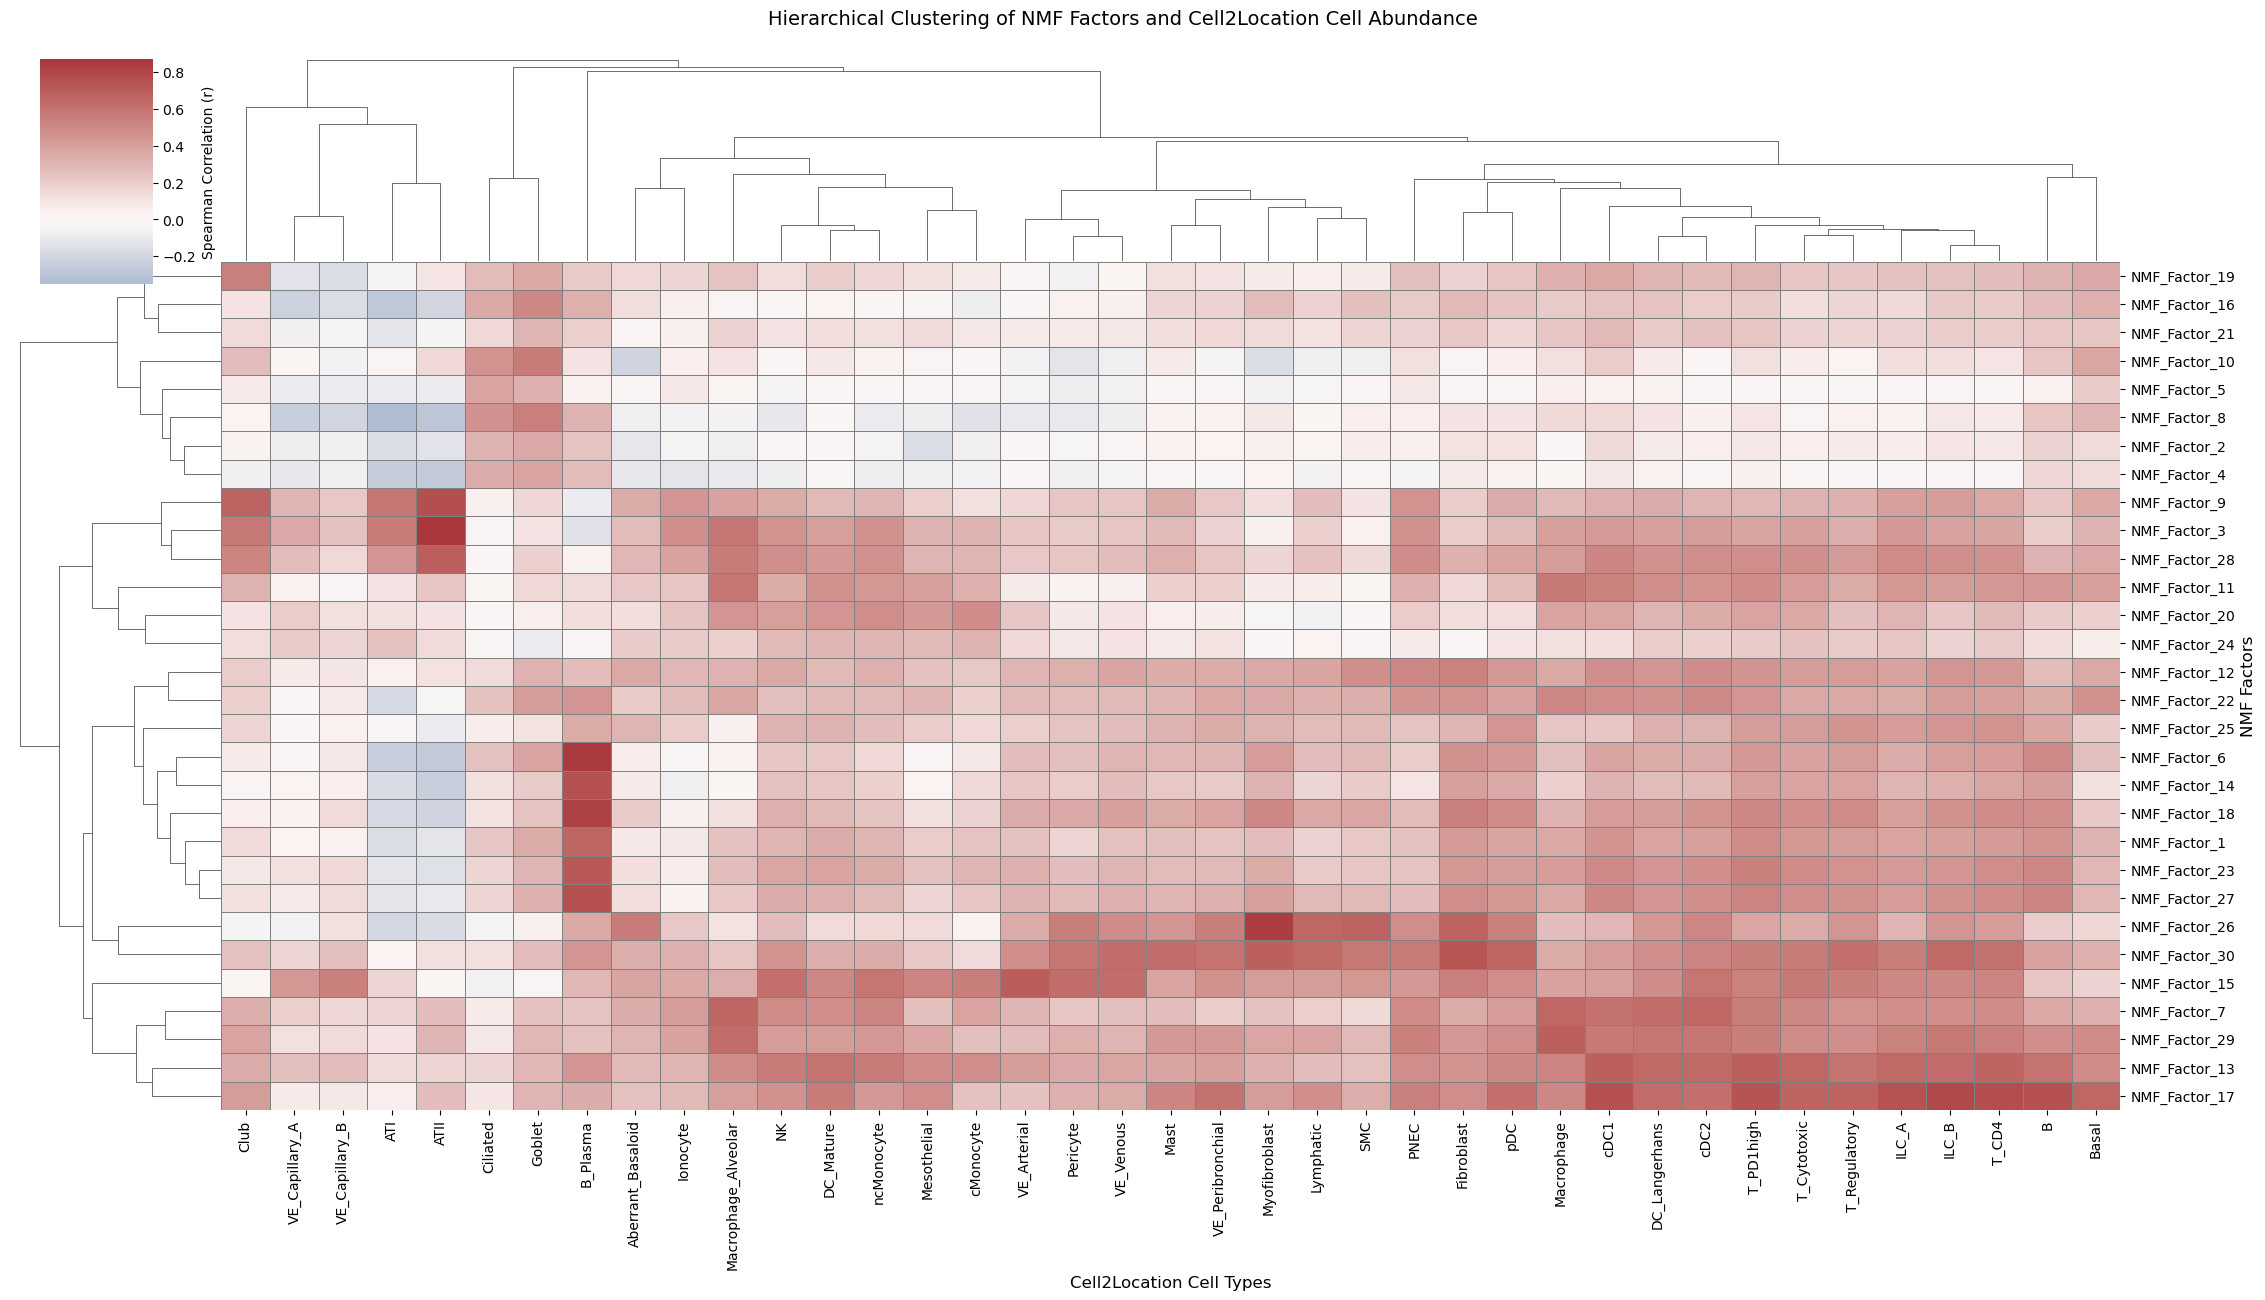


--- Strongest Associations ---
Top correlated NMF Factor (by magnitude) for each Cell Type:
ATI                     NMF_Factor_9
ATII                    NMF_Factor_3
Aberrant_Basaloid      NMF_Factor_26
B                      NMF_Factor_17
B_Plasma                NMF_Factor_6
Basal                  NMF_Factor_17
Ciliated                NMF_Factor_8
Club                    NMF_Factor_9
DC_Langerhans          NMF_Factor_13
DC_Mature              NMF_Factor_13
Fibroblast             NMF_Factor_30
Goblet                 NMF_Factor_10
ILC_A                  NMF_Factor_17
ILC_B                  NMF_Factor_17
Ionocyte                NMF_Factor_3
Lymphatic              NMF_Factor_26
Macrophage             NMF_Factor_29
Macrophage_Alveolar     NMF_Factor_7
Mast                   NMF_Factor_30
Mesothelial            NMF_Factor_15
Myofibroblast          NMF_Factor_26
NK                     NMF_Factor_15
PNEC                   NMF_Factor_30
Pericyte               NMF_Factor_15
SMC                

In [42]:
# Adjust figure size for better visualization of dendrograms
fig_width = len(c2l_cols) * 0.45 + 5
fig_height = len(nmf_cols) * 0.25 + 5

# Use seaborn.clustermap for correlation visualization with hierarchical clustering (dendrogram)
g = sns.clustermap(
    cross_correlation,
    figsize=(fig_width, fig_height),
    method='average',    # Linkage method for clustering (e.g., 'average', 'ward', 'complete')
    metric='euclidean',  # Metric to calculate distances for clustering
    cmap='vlag',         # Divergent colormap
    center=0,            # Center the colorbar at 0 correlation
    linewidths=0.5,
    linecolor='gray',
    dendrogram_ratio=(0.1, 0.2), # Control the size of the dendrograms
    cbar_kws={'label': 'Spearman Correlation (r)'}
)

# Adjust plot labels and rotate ticks for readability
g.ax_heatmap.set_ylabel("NMF Factors", fontsize=12)
g.ax_heatmap.set_xlabel("Cell2Location Cell Types", fontsize=12)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), rotation=0)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), rotation=90)

# Add a main title to the figure
g.fig.suptitle('Hierarchical Clustering of NMF Factors and Cell2Location Cell Abundance', y=1.02, fontsize=14)
g.savefig("/home/jaehyunchoi/bystander_collaboration/Figure_script_IPF/Figures/revision/Visium/Vis_nmf_clustermap.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()

# --- Optional: Identify strongest associations (remains the same) ---
max_corr_per_celltype = cross_correlation.abs().idxmax(axis=0)
print("\n--- Strongest Associations ---")
print("Top correlated NMF Factor (by magnitude) for each Cell Type:")
print(max_corr_per_celltype)